Metrics to measure
- Wasm execution time (in task data)
- Total time (start -> response)
- Proplet CPU time
- Tasks per proplet
- CPU time per proplet
- Tasks per second (different number of clients), tail latencies (throughput)

Tasks have a number of timestamp fields, reflecting the process of execution:
- `start`: start request arrived in scheduler
- `scheduler_decision`: the scheduler decided which proplet will execute the task
- `proplet_arrival`: the task has arrived in the proplet
- `execution_start`: the task will start execution
- `finish`: the task finished execution

# Setup & Helper functions

In [194]:
import json
import requests
import time
import dateutil
import matplotlib.pyplot as plt
import concurrent
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED, as_completed

In [243]:
SCHEDULERS = ["roundrobin", "cpupercent"]
TASKS_URL = "http://localhost:7070/tasks"
THROUGHPUT_CLIENTS = [1, 2]
THROUGHPUT_DURATION = 5 # seconds
REP_COUNTS = [1, 10]
WORKLOADS = {
    "addition": {
        "function_name": "add",
        "path": "addition.wasm",
        "inputs": [10, 20],
        },
    "naive-fib": {
        "function_name": "naive_fib",
        "path": "naive-fib.wasm",
        "inputs": [30],
        },
    "matrix-mul": {
        "function_name": "matrix_mul",
        "path": "matrix-mul.wasm",
        "inputs": [40],
    }
}

In [196]:
def create_task(task_name, task_inputs, scheduler = None) -> str:
    body = {"name": task_name, "inputs": task_inputs}
    if (scheduler):
        body["scheduler"] = scheduler
    resp = requests.post(
        TASKS_URL,
        headers={"Content-Type": "application/json"},
        data=json.dumps(body),
    )
    resp.raise_for_status()
    task_id = resp.json()["id"]
    return task_id

def upload_wasm(task_id, task_location):
    with open(task_location, "rb") as f:
        upload = requests.put(
            f"{TASKS_URL}/{task_id}/upload",
            files={"file": f},
        )
        upload.raise_for_status()

def prepare_tasks(task_count, task_name, task_location, task_inputs, scheduler = None):
    task_ids = []
    for i in range(task_count):
        task_id = create_task(task_name, task_inputs, scheduler)
        upload_wasm(task_id, task_location)
        task_ids.append(task_id)
    return task_ids

In [197]:
def start_task(task_id):
    resp = requests.post(f"{TASKS_URL}/{task_id}/start")
    resp.raise_for_status()

def start_tasks(task_ids):
    for task_id in task_ids:
        start_task(task_id)

In [198]:
def get_task_result(task_id):
    while True:
        resp = requests.get(f"{TASKS_URL}/{task_id}")
        resp.raise_for_status()
        data = resp.json()
        if "results" in data:
            return data
            break
        time.sleep(0.005)

def get_tasks_results(task_ids):
    results = []
    for task_id in task_ids:
        data = get_task_result(task_id)
        results.append(data)
    return results

In [199]:
def execute_benchmark(function_name, task_location, task_inputs, task_count = 1, scheduler = None):
    print(f"Starting test execution for task: {function_name}")

    task_ids = prepare_tasks(task_count, function_name, task_location, task_inputs, scheduler)
    print("Prepared all tasks successfully")

    start_execution = time.perf_counter_ns()

    start_tasks(task_ids)
    print("Started all tasks successfully")

    results = get_tasks_results(task_ids)
    
    duration = (time.perf_counter_ns() - start_execution) * 1000 # ms
    print(f"Retrieved all task results successfully, start to finish took {duration} ms")

    return results, duration

In [200]:
def _submit_task_start(workload, input_data, scheduler, task_location):
    task_id = create_task(workload, input_data, scheduler)
    upload_wasm(task_id, task_location)
    start_task(task_id)
    return task_id

def _to_unix_seconds(ts):
    if ts is None:
        return None
    if isinstance(ts, (int, float)):
        return float(ts)
    return dateutil.parser.isoparse(ts).timestamp()

In [238]:
def throughput_benchmark(scheduler, workload, input_data, task_location, concurrency, duration_sec=30):
    submitted_task_ids = []
    submit_start = time.time()
    submit_deadline = submit_start + duration_sec

    with ThreadPoolExecutor(max_workers=concurrency) as executor:
        in_flight = set()

        # Submit as many starts as possible during the time window
        while time.time() < submit_deadline:
            while len(in_flight) < concurrency and time.time() < submit_deadline:
                fut = executor.submit(_submit_task_start, workload, input_data, scheduler, task_location)
                in_flight.add(fut)

            done, _ = wait(in_flight, timeout=0.0, return_when=FIRST_COMPLETED)
            for fut in done:
                in_flight.remove(fut)
                try:
                    task_id = fut.result()
                    submitted_task_ids.append(task_id)
                except Exception:
                    pass

        # Collect remaining submitted futures
        for fut in as_completed(in_flight):
            try:
                task_id = fut.result()
                submitted_task_ids.append(task_id)
            except Exception:
                pass

    # Cutoff = "current time" right after submission phase
    cutoff_unix = time.time()

    finished_before_cutoff = []
    for task_id in submitted_task_ids:
        try:
            data = get_task_result(task_id)  # blocks until task has results
            finish_unix = _to_unix_seconds(data.get("finish_time"))
            if finish_unix is not None and finish_unix <= cutoff_unix:
                finished_before_cutoff.append(data)
        except Exception:
            pass

    throughput = len(finished_before_cutoff) / duration_sec

    return {
        "submitted": len(submitted_task_ids),
        "completed_before_cutoff": len(finished_before_cutoff),
        "throughput_tps": throughput,
        "cutoff_unix": cutoff_unix,
        "results_before_cutoff": finished_before_cutoff,
    }

# Benchmark Execution

## Latency

In [214]:
results = {}

for scheduler in SCHEDULERS:
    for task_name, task_info in WORKLOADS.items():
        for rep_count in REP_COUNTS:
            print(f"Running benchmark for scheduler: {scheduler}, task: {task_name}, rep count: {rep_count}")
            task_results, duration = execute_benchmark(
                function_name=task_info["function_name"],
                task_count=rep_count,
                task_location=f"build/{task_name}.wasm",
                task_inputs=task_info["inputs"],
                scheduler=scheduler
            )
            results[f"{scheduler}_{task_name}_{rep_count}"] = {
                "results": task_results,
                "duration": duration,
            }

Running benchmark for scheduler: roundrobin, task: addition, rep count: 1
Starting test execution for task: add
Prepared all tasks successfully
Started all tasks successfully
Retrieved all task results successfully, start to finish took 201941454000 ms
Running benchmark for scheduler: roundrobin, task: addition, rep count: 10
Starting test execution for task: add
Prepared all tasks successfully
Started all tasks successfully
Retrieved all task results successfully, start to finish took 641657055000 ms
Running benchmark for scheduler: roundrobin, task: naive-fib, rep count: 1
Starting test execution for task: naive_fib
Prepared all tasks successfully
Started all tasks successfully
Retrieved all task results successfully, start to finish took 980068573000 ms
Running benchmark for scheduler: roundrobin, task: naive-fib, rep count: 10
Starting test execution for task: naive_fib
Prepared all tasks successfully
Started all tasks successfully
Retrieved all task results successfully, start to 

## Throughput

In [244]:
throughput_benchmark_results = {}

for scheduler in SCHEDULERS:
    print(f"Running throughput benchmark for scheduler: {scheduler}")
    for task_name, task_info in WORKLOADS.items():
        print(f"Running throughput benchmark for task: {task_name}")
        for concurrency in THROUGHPUT_CLIENTS:
            result = throughput_benchmark(
                scheduler=scheduler,
                workload=task_info["function_name"],
                input_data=task_info["inputs"],
                task_location=f"build/{task_name}.wasm",
                concurrency=concurrency,
                duration_sec=THROUGHPUT_DURATION
            )
            throughput_benchmark_results[f"{scheduler}_{task_name}_{concurrency}"] = {
                "scheduler": scheduler,
                "task": task_name,
                "concurrency": concurrency,
                "submitted": result["submitted"],
                "completed_before_cutoff": result["completed_before_cutoff"],
                "throughput_tps": result["throughput_tps"],
            }

Running throughput benchmark for scheduler: roundrobin
Running throughput benchmark for task: addition
Running throughput benchmark for task: naive-fib
Running throughput benchmark for task: matrix-mul
Running throughput benchmark for scheduler: cpupercent
Running throughput benchmark for task: addition
Running throughput benchmark for task: naive-fib
Running throughput benchmark for task: matrix-mul


# Results

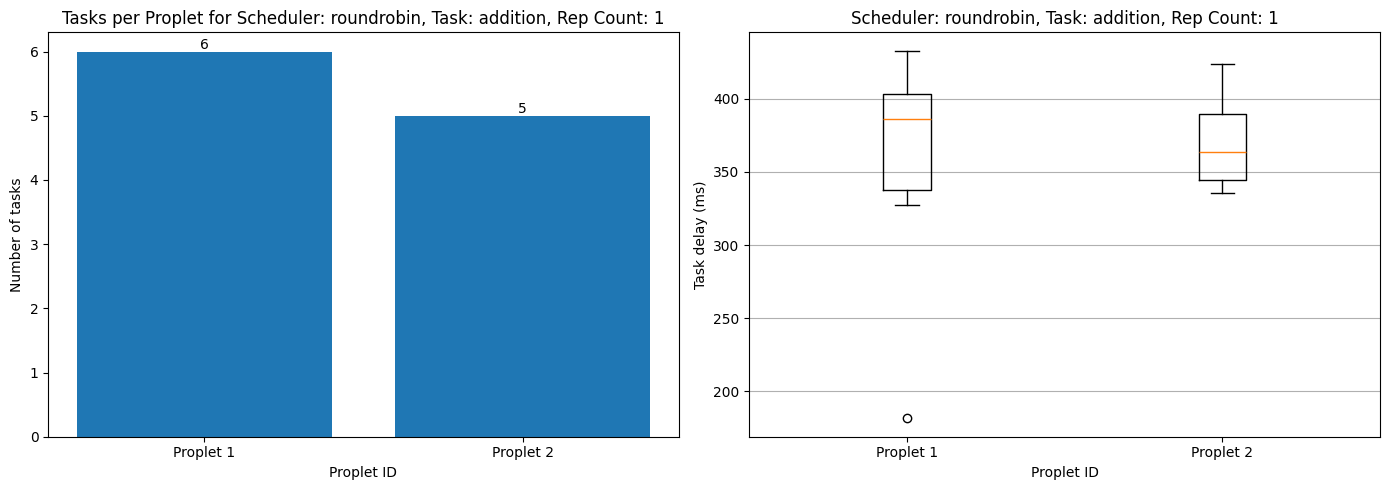

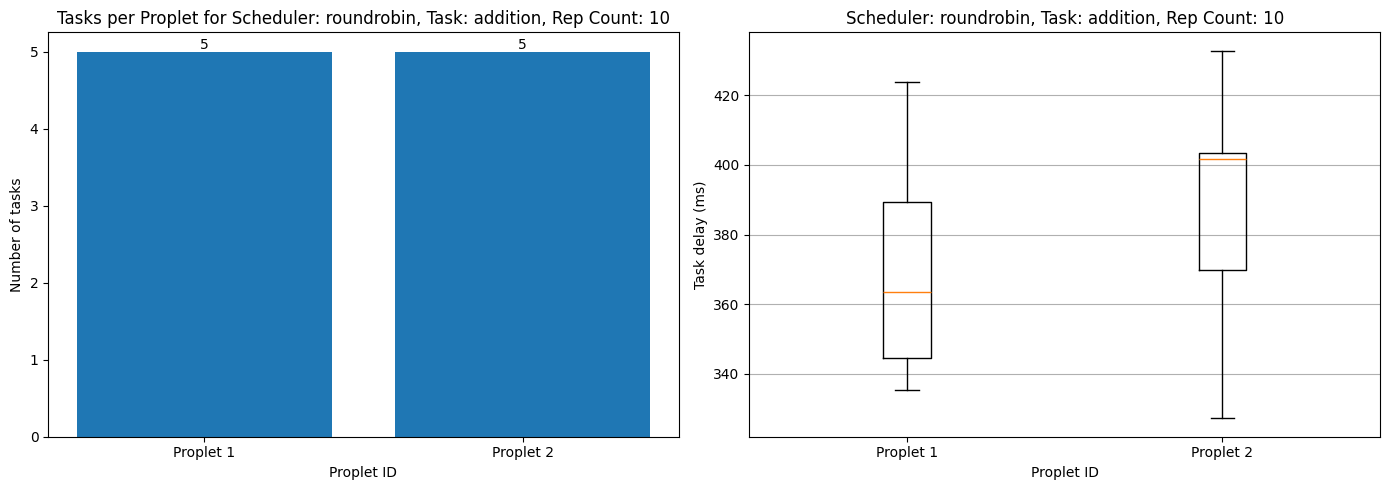

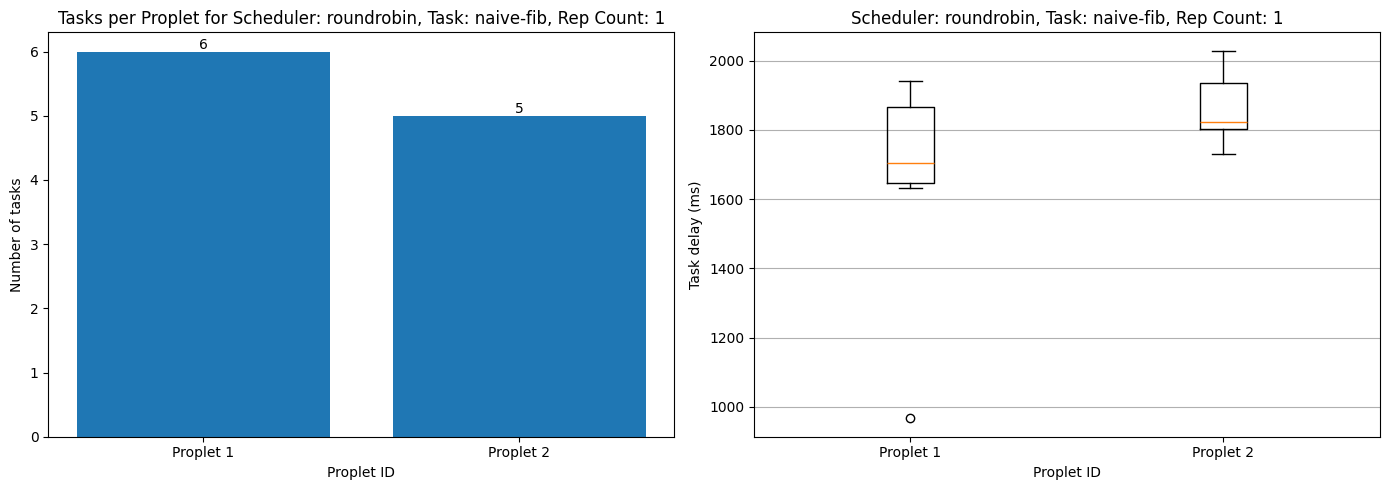

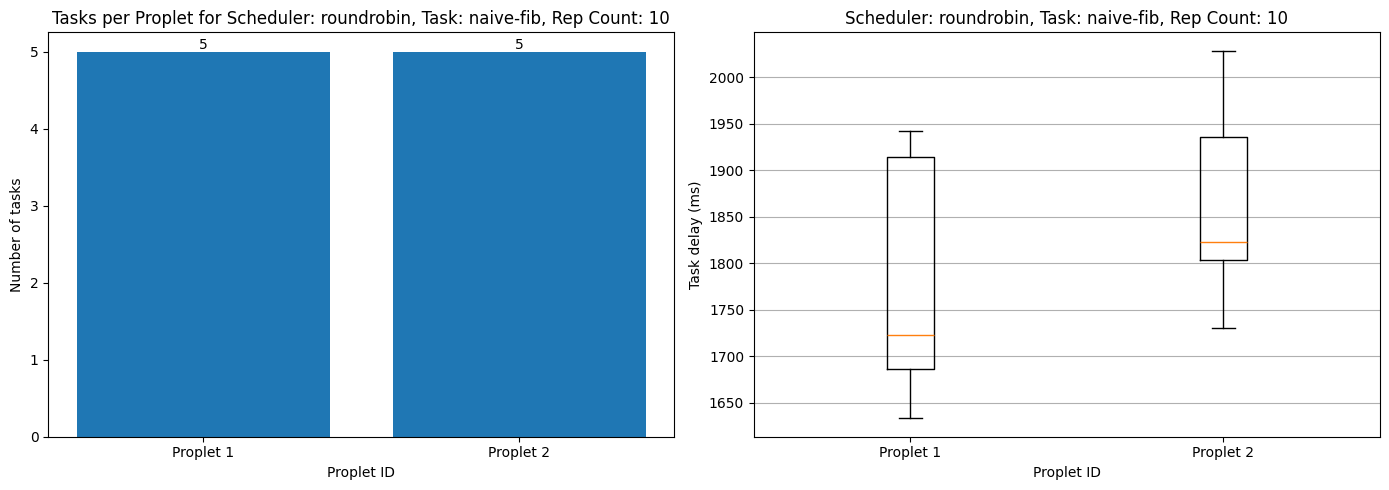

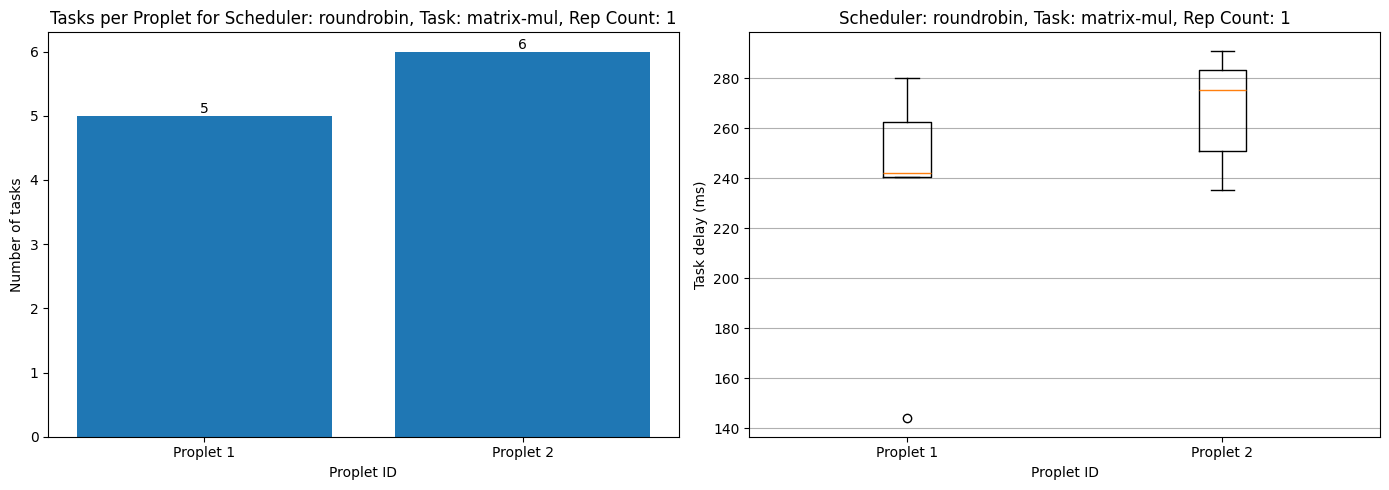

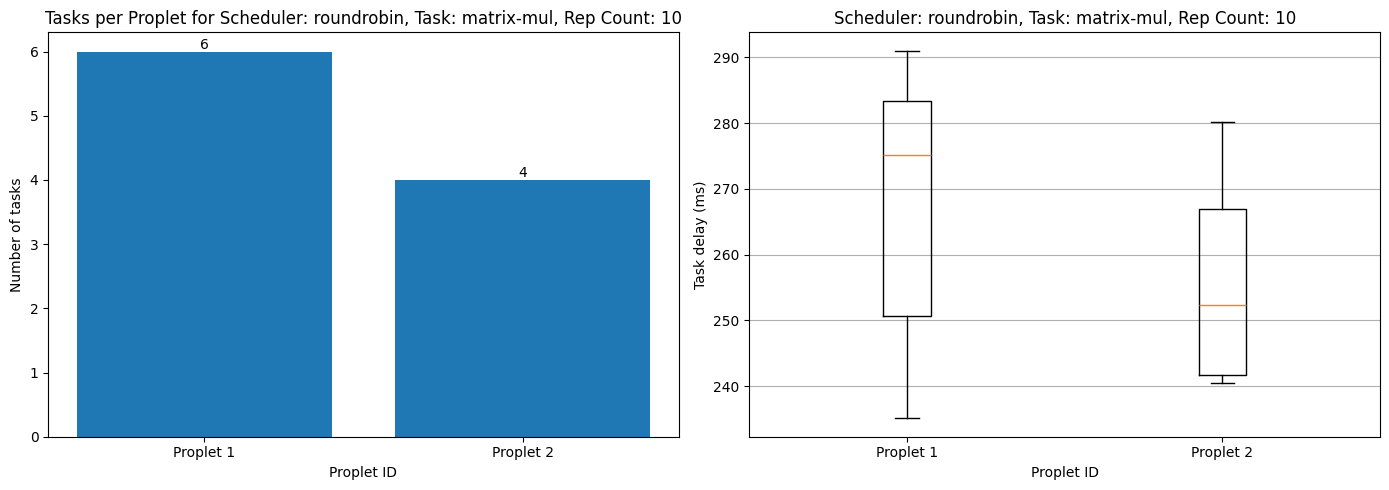

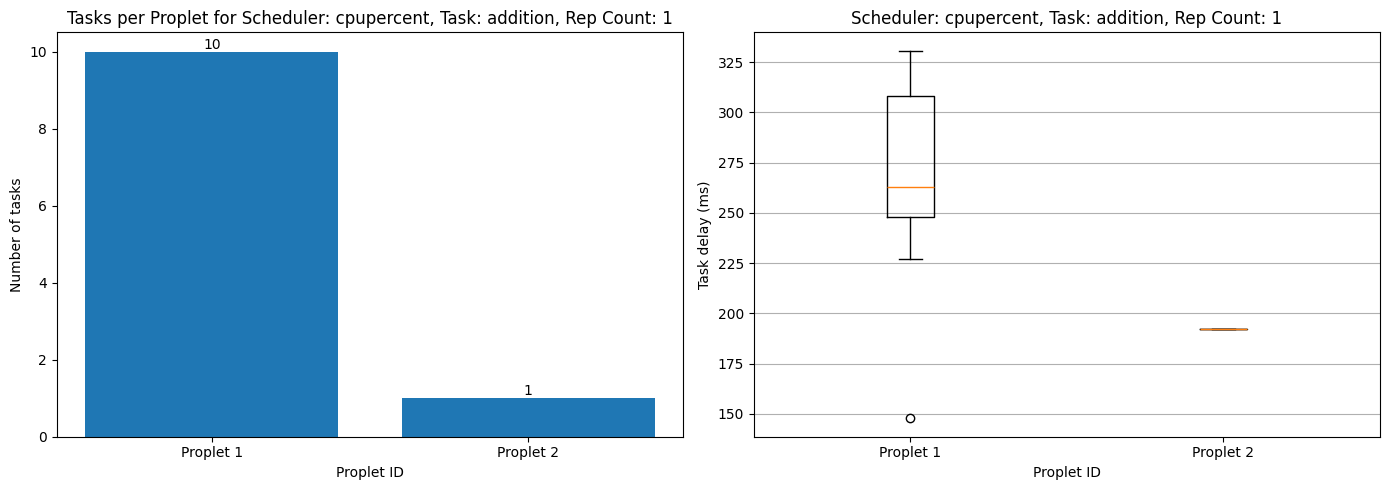

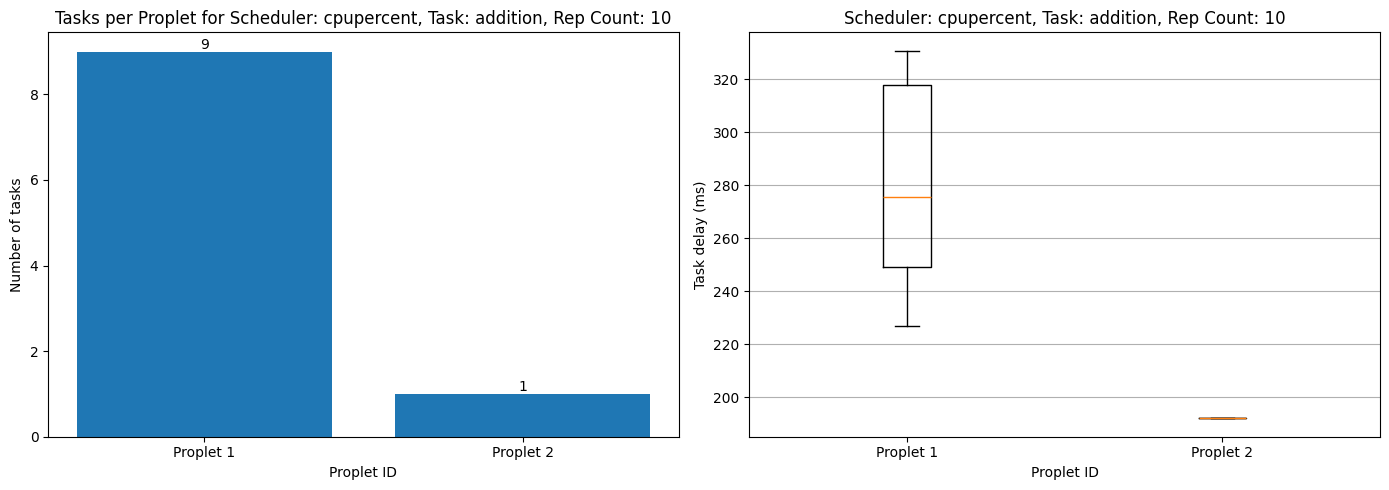

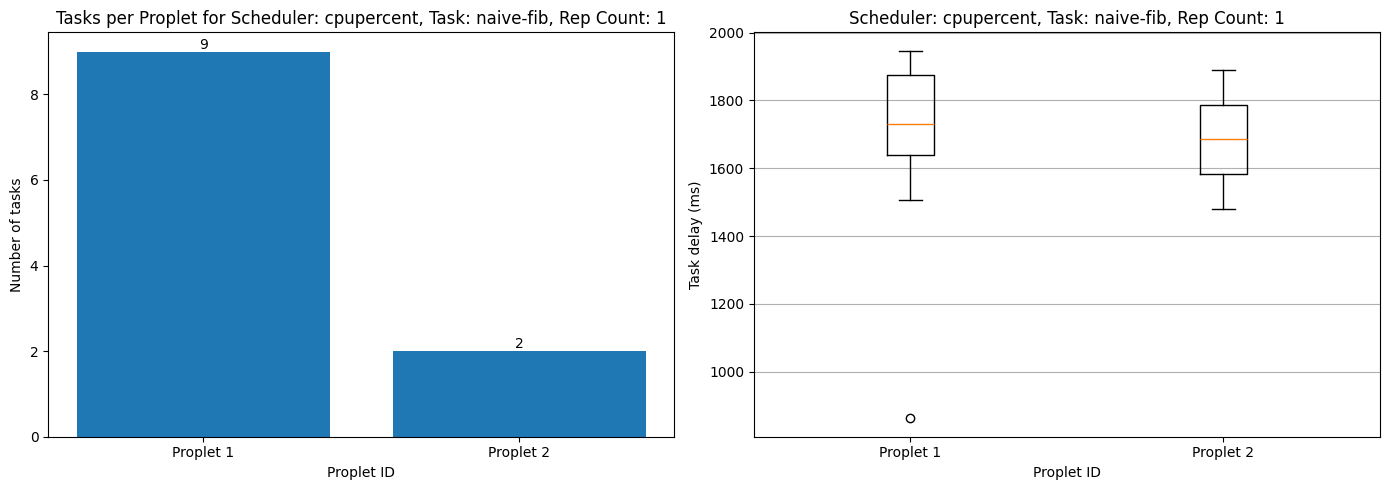

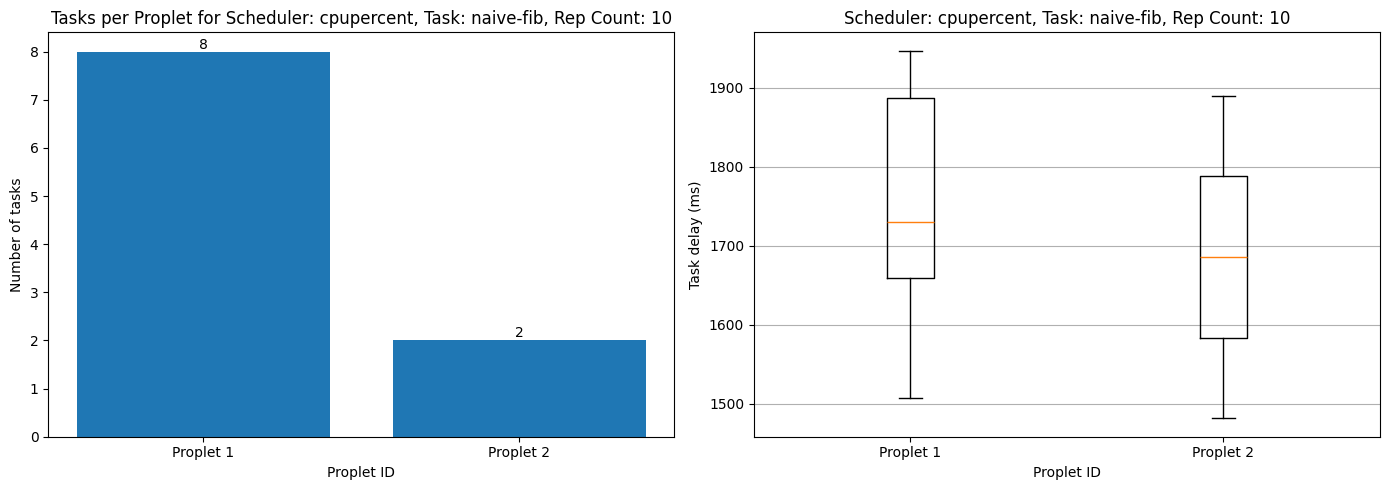

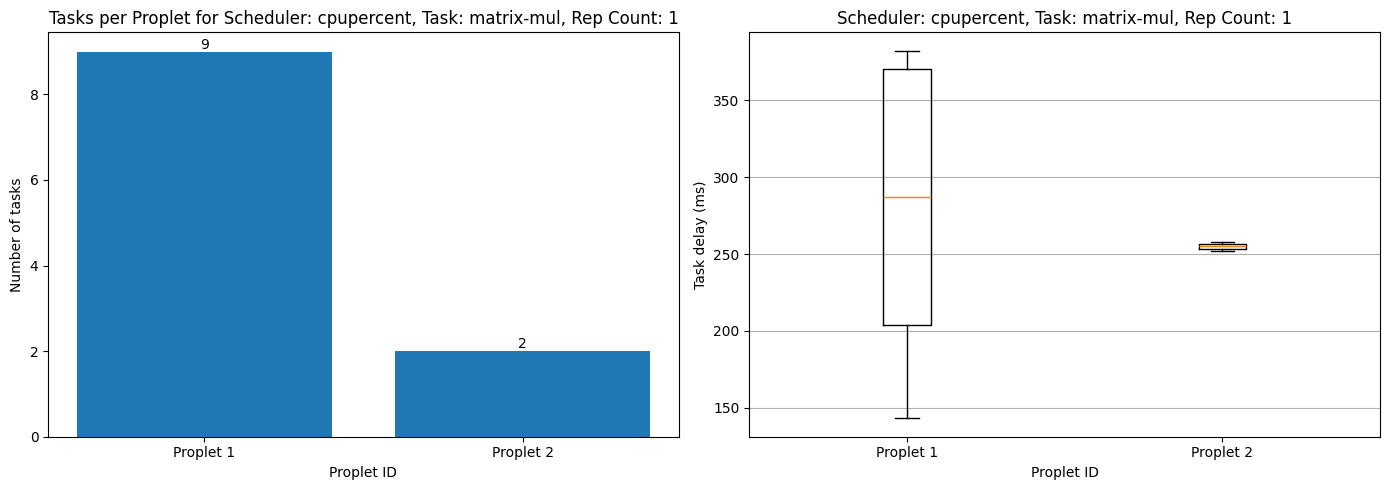

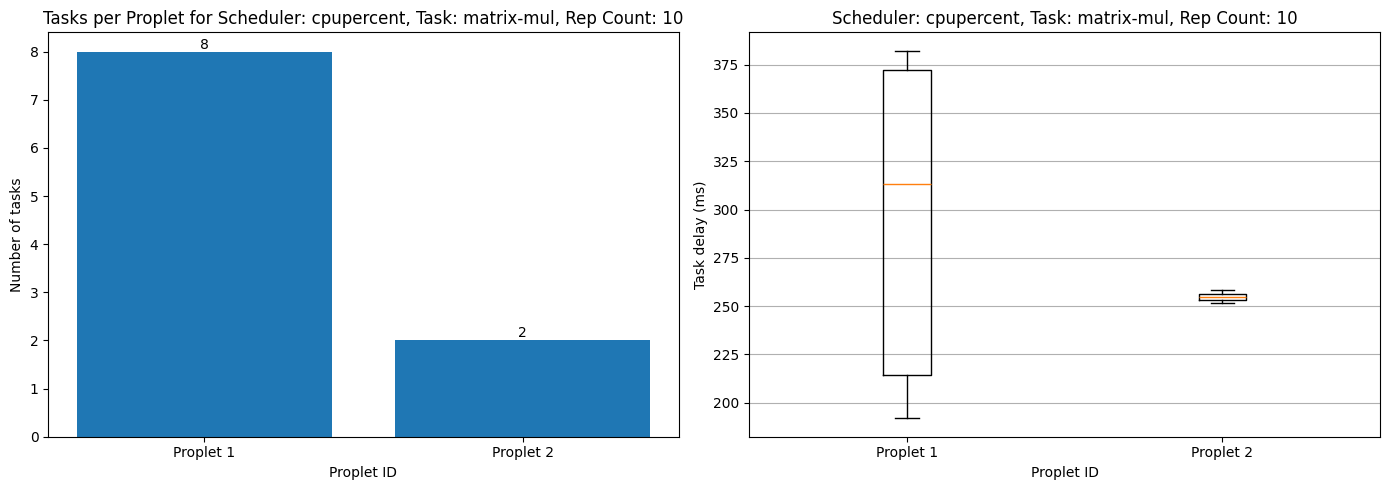

In [218]:
for scheduler in SCHEDULERS:
    for task_name in WORKLOADS.keys():
        for rep_count in REP_COUNTS:
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

            # Plot histogram of the number of tasks per proplet ID, grouped by scheduler and task type
            proplet_counts = {}
            for key, value in results.items():
                    if key.startswith(f"{scheduler}_{task_name}_{rep_count}"):
                        for task_result in value["results"]:
                            proplet_id = task_result["proplet_id"]
                            if proplet_id not in proplet_counts:
                                proplet_counts[proplet_id] = 0
                            proplet_counts[proplet_id] += 1
            proplet_counts = {f"Proplet {i+1}": count for i, (proplet_id, count) in enumerate(proplet_counts.items())}
            
            # plot the number on top of each bar
            bars = ax1.bar(proplet_counts.keys(), proplet_counts.values())
            for bar in bars:
                height = bar.get_height()
                ax1.text(bar.get_x() + bar.get_width()/2., height,
                         f'{height}',
                         ha='center', va='bottom')
            
            ax1.set_xlabel("Proplet ID")
            ax1.set_ylabel("Number of tasks")
            ax1.set_title(f"Tasks per Proplet for Scheduler: {scheduler}, Task: {task_name}, Rep Count: {rep_count}")

            
            # Plot delay per task, y axis is delay in ms, x axis is proplet ID
            proplet_delays = {}
            for key, value in results.items():
                    if key.startswith(f"{scheduler}_{task_name}_{rep_count}"):
                        for task_result in value["results"]:
                            proplet_id = task_result["proplet_id"]
                            start_ts = _to_unix_seconds(task_result.get("start_time"))
                            finish_ts = _to_unix_seconds(task_result.get("finish_time"))
                            if start_ts is None or finish_ts is None:
                                continue
                            delay_ms = (finish_ts - start_ts) * 1000
                            if proplet_id not in proplet_delays:
                                proplet_delays[proplet_id] = []
                            proplet_delays[proplet_id].append(delay_ms)
            proplet_delays = {f"Proplet {i+1}": delays for i, (proplet_id, delays) in enumerate(proplet_delays.items())}
            ax2.boxplot(proplet_delays.values(), tick_labels=proplet_delays.keys())
            ax2.set_xlabel("Proplet ID")
            ax2.set_ylabel("Task delay (ms)")
            ax2.set_title(f"Scheduler: {scheduler}, Task: {task_name}, Rep Count: {rep_count}")
            ax2.yaxis.grid(True)
            plt.tight_layout()
            plt.show()

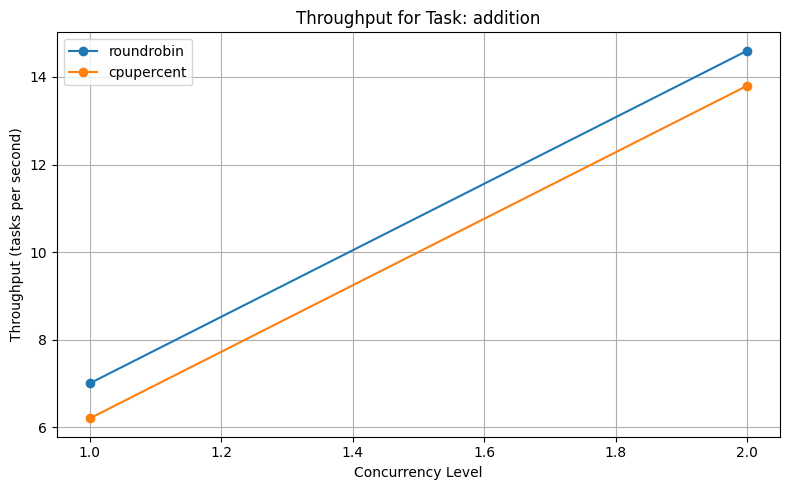

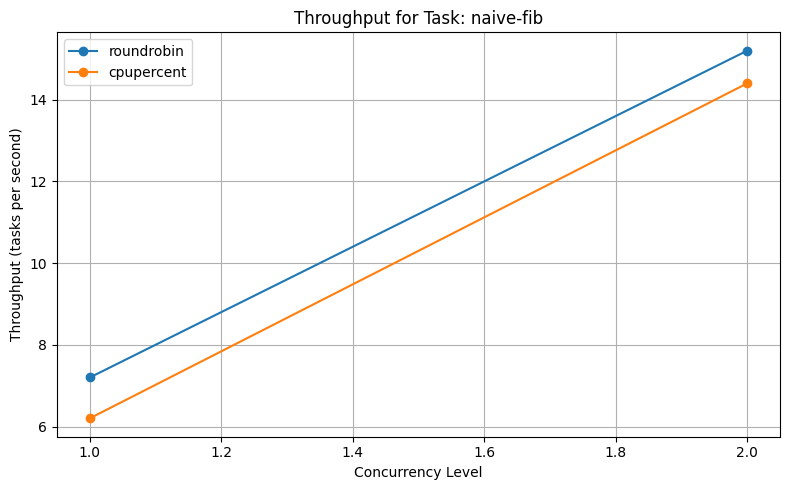

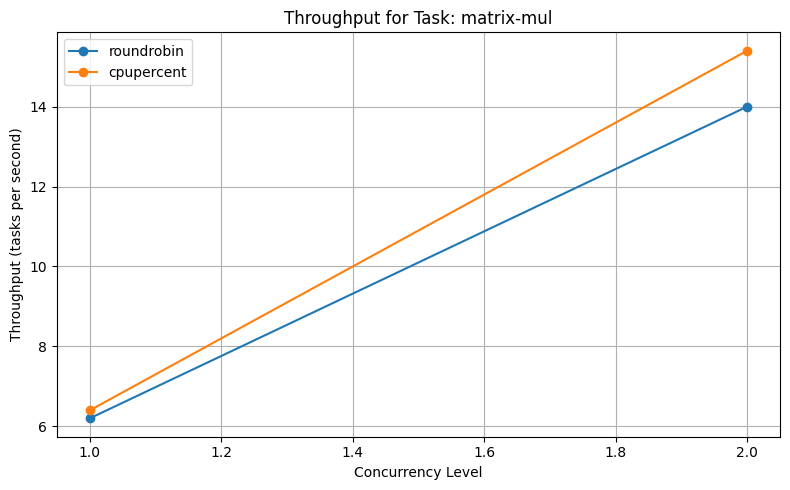

In [245]:
for task_name in WORKLOADS.keys():
    fig, ax = plt.subplots(figsize=(8, 5))
    for scheduler in SCHEDULERS:
        throughputs = []
        for concurrency in THROUGHPUT_CLIENTS:
            result = throughput_benchmark_results.get(f"{scheduler}_{task_name}_{concurrency}")
            if result:
                throughputs.append(result["throughput_tps"])
            else:
                throughputs.append(0)
        ax.plot(THROUGHPUT_CLIENTS, throughputs, marker='o', label=scheduler)
    ax.set_xlabel("Concurrency Level")
    ax.set_ylabel("Throughput (tasks per second)")
    ax.set_title(f"Throughput for Task: {task_name}")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()